(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

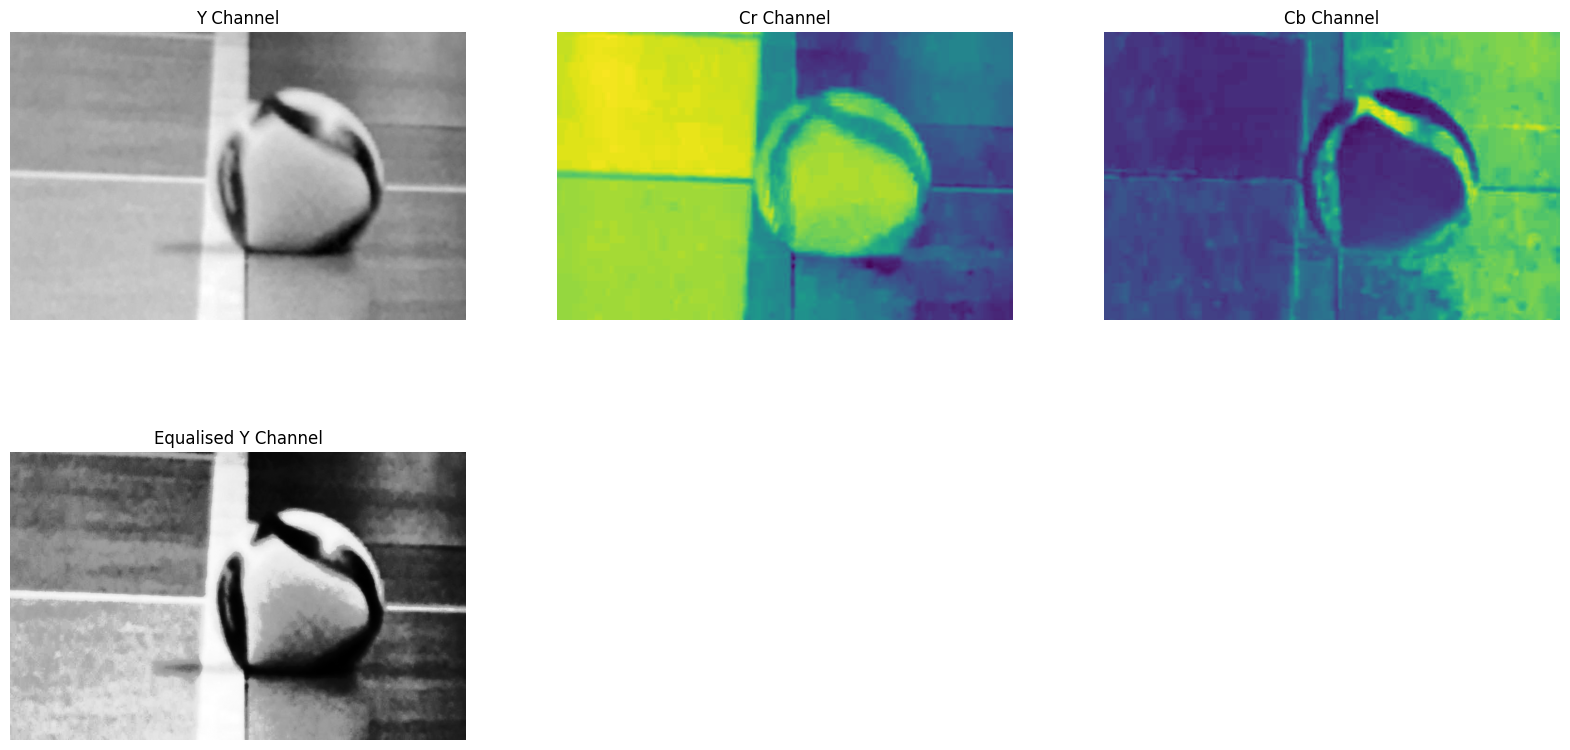

In [65]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image = cv.imread('vbImages/sampleImgVB_1.jpg')
YCrCb = cv.cvtColor(image, cv.COLOR_BGR2YCrCb)

Y, Cr, Cb = cv.split(YCrCb)
equalised_y = cv.equalizeHist(Y)
YCrCb_eq = cv.merge((equalised_y, Cr, Cb))

plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
plt.title('Y Channel')
plt.imshow(Y, cmap='gray')
plt.axis('off')
plt.subplot(2,3,2)
plt.title('Cr Channel')
plt.imshow(Cr)
plt.axis('off')
plt.subplot(2,3,3)
plt.title('Cb Channel')
plt.imshow(Cb)
plt.axis('off')
plt.subplot(2,3,4)
plt.title('Equalised Y Channel')
plt.imshow(equalised_y, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

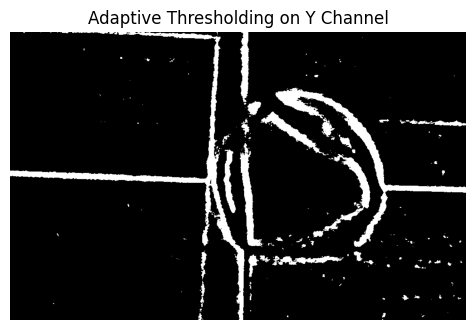

In [ ]:
# Apply adaptive thresholding to the Y channel to filter out lines
Y = cv.medianBlur(Y, 3)
adaptive_thresh = cv.adaptiveThreshold(Y, maxValue=255, adaptiveMethod=cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       thresholdType=cv.THRESH_BINARY, blockSize=49, C=-5)


plt.figure(figsize=(20,10))
plt.subplot(2,3,5)
plt.title('Adaptive Thresholding on Y Channel')
plt.imshow(adaptive_thresh, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

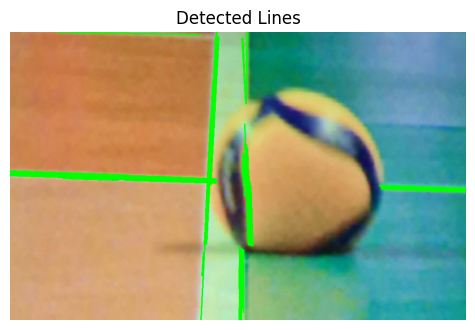

In [ ]:
# Detect the inner and outer edge of the court line using hough transform
lines = cv.HoughLinesP(adaptive_thresh, rho=1, theta=np.pi/180, threshold=250,
                        minLineLength=50, maxLineGap=10)

line_image = image.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv.line(line_image, pt1=(x1, y1), pt2=(x2, y2), color=(0, 255, 0), thickness=2)

plt.figure(figsize=(20,10))
plt.subplot(2,3,6)
plt.title('Detected Lines')
plt.imshow(cv.cvtColor(line_image, cv.COLOR_BGR2RGB))
plt.axis('off')